# kang study: CLAP audio + CLAP text + class MLP

이 노트북은 confidence 1-5 분류를 최대한 단순한 조건에서 확인하기 위한 실험입니다.

사용 feature:

- CLAP audio embedding, 512 dim
- CLAP text embedding, 512 dim
- second-level class one-hot

사용하지 않는 feature:

- title length, tag count, description length, has description
- class_top one-hot
- handcrafted cosine/L2/norm feature
- ensemble, stacking, two-tower

확인할 것:

- 5-fold OOF classification 성능
- Accuracy, balanced accuracy, macro F1, QWK, MAE, Spearman
- confusion matrix로 class가 얼마나 맞는지
- true confidence별 predicted score 분포
- MLP hidden embedding에서 confidence가 군집화되는지

In [1]:
from pathlib import Path
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    mean_absolute_error,
    precision_recall_fscore_support,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
METADATA_DIR = DATA_DIR / "metadata"
FEATURE_DIR = DATA_DIR / "features"

OUT_DIR = ROOT / "outputs" / "kang_study"
REPORT_DIR = OUT_DIR / "reports"
PRED_DIR = OUT_DIR / "predictions"
PLOT_DIR = OUT_DIR / "plots"
CKPT_DIR = OUT_DIR / "checkpoints"
for path in [REPORT_DIR, PRED_DIR, PLOT_DIR, CKPT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed": 42,
    "folds": 5,
    "epochs": 50,
    "patience": 7,
    "batch_size": 256,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "hidden": (512, 256),
    "loss_name": "emd",  # "emd" or "ce"
    "tsne_sample_n": 3000,
    "bsd10k_metadata": METADATA_DIR / "BSD10k_metadata.csv",
    "bsd35k_metadata": METADATA_DIR / "BSD35k-CS_metadata.csv",
    "bsd10k_audio_dir": FEATURE_DIR / "clap_audio_embeddings",
    "bsd10k_text_dir": FEATURE_DIR / "clap_text_embeddings",
    "bsd35k_audio_dir": FEATURE_DIR / "BSD35k_clap_audio_embeddings",
    "bsd35k_text_dir": FEATURE_DIR / "BSD35k-CS_clap_text_embeddings",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL_VALUES_NP = np.arange(1, 6, dtype=np.float32)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("device:", DEVICE)
print("output dir:", OUT_DIR)

device: cuda
output dir: c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study


In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def clean_metadata(df, require_confidence):
    df = df.copy()
    df["sound_id"] = df["sound_id"].astype(str).str.strip()
    df["class"] = df["class"].astype(str).str.strip()
    if "class_top" not in df.columns:
        df["class_top"] = df["class"].str.split("-").str[0]
    else:
        df["class_top"] = df["class_top"].fillna(df["class"].str.split("-").str[0]).astype(str).str.strip()

    class_idx = df["class_idx"].astype(str).str.strip()
    keep = ~((class_idx.str.len() == 3) & (class_idx.str.endswith("99") | class_idx.str.endswith("00")))
    df = df[keep].copy()

    if require_confidence:
        df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")
        df = df[df["confidence"].isin([1, 2, 3, 4, 5])].copy()
        df["confidence"] = df["confidence"].astype(int)

    return df.reset_index(drop=True)


def one_hot(values, categories):
    index = {cat: idx for idx, cat in enumerate(categories)}
    arr = np.zeros((len(values), len(categories)), dtype=np.float32)
    for row_idx, value in enumerate(values):
        col_idx = index.get(str(value))
        if col_idx is not None:
            arr[row_idx, col_idx] = 1.0
    return arr


def load_embeddings_and_df(df, audio_dir, text_dir):
    audio_rows = []
    text_rows = []
    kept = []

    for idx, row in df.reset_index(drop=True).iterrows():
        sound_id = str(row["sound_id"])
        audio_path = audio_dir / f"{sound_id}.npy"
        text_path = text_dir / f"{sound_id}.npy"
        if audio_path.is_file() and text_path.is_file():
            audio_rows.append(np.load(audio_path).reshape(-1).astype(np.float32))
            text_rows.append(np.load(text_path).reshape(-1).astype(np.float32))
            kept.append(idx)

    if not kept:
        raise RuntimeError("No rows had both audio and text embeddings.")

    kept_df = df.reset_index(drop=True).iloc[kept].reset_index(drop=True).copy()
    audio = np.vstack(audio_rows).astype(np.float32)
    text = np.vstack(text_rows).astype(np.float32)
    return kept_df, audio, text


def build_feature_matrix(df, audio_dir, text_dir, class_categories):
    kept_df, audio, text = load_embeddings_and_df(df, audio_dir, text_dir)
    class_x = one_hot(kept_df["class"].astype(str).tolist(), class_categories)
    x = np.hstack([audio, text, class_x]).astype(np.float32)
    return kept_df, x


seed_everything(CONFIG["seed"])

In [3]:
bsd10k_raw = pd.read_csv(CONFIG["bsd10k_metadata"])
bsd10k = clean_metadata(bsd10k_raw, require_confidence=True)
class_categories = sorted(bsd10k["class"].astype(str).unique().tolist())

bsd10k_df, x_raw = build_feature_matrix(
    bsd10k,
    CONFIG["bsd10k_audio_dir"],
    CONFIG["bsd10k_text_dir"],
    class_categories,
)
y_1based = bsd10k_df["confidence"].to_numpy(dtype=np.int64)
y_0based = y_1based - 1

print("rows:", len(bsd10k_df))
print("input_dim:", x_raw.shape[1])
print("feature dims: audio=512, text=512, class=", len(class_categories))
print("class categories:", class_categories)

dist = pd.Series(y_1based).value_counts().sort_index().rename_axis("confidence").reset_index(name="n")
dist["rate"] = dist["n"] / dist["n"].sum()
display(dist)

rows: 10956
input_dim: 1047
feature dims: audio=512, text=512, class= 23
class categories: ['fx-a', 'fx-el', 'fx-ex', 'fx-h', 'fx-m', 'fx-n', 'fx-o', 'fx-v', 'is-e', 'is-k', 'is-p', 'is-s', 'is-w', 'm-m', 'm-si', 'm-sp', 'sp-c', 'sp-p', 'sp-s', 'ss-i', 'ss-n', 'ss-s', 'ss-u']


,confidence,n,rate
0,1,106,0.009675
1,2,749,0.068364
2,3,3280,0.299379
3,4,6045,0.551752
4,5,776,0.070829


In [4]:
class ConfidenceDataset(Dataset):
    def __init__(self, x, y=None):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        item = {"x": self.x[idx]}
        if self.y is not None:
            item["y"] = self.y[idx]
        return item


class ConfidenceMLP(nn.Module):
    def __init__(self, input_dim, n_classes=5, hidden=(512, 256), dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(input_dim, hidden[0]),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[0], hidden[1]),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(hidden[1], n_classes)

    def forward_features(self, x):
        return self.features(x)

    def forward(self, x):
        return self.classifier(self.forward_features(x))


def expected_score_from_probs(probs):
    return (probs * LABEL_VALUES_NP.reshape(1, -1)).sum(axis=1)


def compute_loss(logits, y, loss_name="emd"):
    if loss_name == "ce":
        return F.cross_entropy(logits, y)

    if loss_name == "emd":
        probs = F.softmax(logits, dim=1)
        true = F.one_hot(y, num_classes=5).float()
        pred_cdf = probs.cumsum(dim=1)
        true_cdf = true.cumsum(dim=1)
        return torch.mean((pred_cdf - true_cdf) ** 2)

    raise ValueError(loss_name)


def predict_probs_and_features(model, loader):
    model.eval()
    probs = []
    feats = []
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(DEVICE)
            h = model.forward_features(x)
            logits = model.classifier(h)
            probs.append(F.softmax(logits, dim=1).cpu().numpy())
            feats.append(h.cpu().numpy())
    return np.vstack(probs).astype(np.float32), np.vstack(feats).astype(np.float32)


print(ConfidenceMLP(x_raw.shape[1], hidden=CONFIG["hidden"], dropout=CONFIG["dropout"]))

ConfidenceMLP(
  (features): Sequential(
    (0): Linear(in_features=1047, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.3, inplace=False)
  )
  (classifier): Linear(in_features=256, out_features=5, bias=True)
)


In [5]:
def metrics_from_probs(y_true_1based, probs):
    score = expected_score_from_probs(probs)
    pred_class = probs.argmax(axis=1) + 1
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_1based,
        pred_class,
        average="macro",
        zero_division=0,
    )
    rho = spearmanr(y_true_1based, score).statistic
    return {
        "mae_expected_score": float(mean_absolute_error(y_true_1based, score)),
        "spearman_expected_score": float(0.0 if np.isnan(rho) else rho),
        "accuracy": float(accuracy_score(y_true_1based, pred_class)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true_1based, pred_class)),
        "quadratic_weighted_kappa": float(cohen_kappa_score(y_true_1based, pred_class, weights="quadratic")),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
    }


def per_class_metrics_df(y_true, probs):
    pred = probs.argmax(axis=1) + 1
    report = classification_report(y_true, pred, labels=[1, 2, 3, 4, 5], output_dict=True, zero_division=0)
    rows = []
    for cls in [1, 2, 3, 4, 5]:
        item = report[str(cls)]
        rows.append({
            "confidence": cls,
            "precision": item["precision"],
            "recall": item["recall"],
            "f1": item["f1-score"],
            "support": int(item["support"]),
        })
    return pd.DataFrame(rows)


def train_one_fold(fold, train_idx, valid_idx):
    seed_everything(CONFIG["seed"] + fold)

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_raw[train_idx]).astype(np.float32)
    x_valid = scaler.transform(x_raw[valid_idx]).astype(np.float32)

    train_loader = DataLoader(
        ConfidenceDataset(x_train, y_0based[train_idx]),
        batch_size=CONFIG["batch_size"],
        shuffle=True,
    )
    valid_loader = DataLoader(ConfidenceDataset(x_valid), batch_size=CONFIG["batch_size"], shuffle=False)

    model = ConfidenceMLP(x_raw.shape[1], hidden=CONFIG["hidden"], dropout=CONFIG["dropout"]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

    best_mae = math.inf
    best_epoch = -1
    best_state = None
    stale = 0
    history = []

    for epoch in range(CONFIG["epochs"]):
        model.train()
        total_loss = 0.0
        seen = 0

        for batch in train_loader:
            xb = batch["x"].to(DEVICE)
            yb = batch["y"].to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = compute_loss(model(xb), yb, CONFIG["loss_name"])
            loss.backward()
            optimizer.step()
            total_loss += float(loss.item()) * xb.shape[0]
            seen += xb.shape[0]

        scheduler.step()
        probs, _ = predict_probs_and_features(model, valid_loader)
        val_mae = mean_absolute_error(y_1based[valid_idx], expected_score_from_probs(probs))
        val_acc = accuracy_score(y_1based[valid_idx], probs.argmax(axis=1) + 1)
        history.append({"epoch": epoch, "train_loss": total_loss / max(seen, 1), "val_mae": float(val_mae), "val_accuracy": float(val_acc)})

        if val_mae < best_mae - 1e-6:
            best_mae = float(val_mae)
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= CONFIG["patience"]:
                break

    model.load_state_dict(best_state)
    probs, hidden = predict_probs_and_features(model, valid_loader)

    torch.save(
        {
            "model_state": best_state,
            "input_dim": int(x_raw.shape[1]),
            "scaler_mean": scaler.mean_.astype(np.float32),
            "scaler_scale": scaler.scale_.astype(np.float32),
            "class_categories": class_categories,
            "config": CONFIG,
            "best_epoch": int(best_epoch),
        },
        CKPT_DIR / f"fold_{fold}.pt",
    )
    pd.DataFrame(history).to_csv(REPORT_DIR / f"fold_{fold}_history.csv", index=False)

    return probs, hidden, {"fold": fold, "best_epoch": int(best_epoch), "best_mae": float(best_mae)}

In [6]:
start = time.time()
splitter = StratifiedKFold(n_splits=CONFIG["folds"], shuffle=True, random_state=CONFIG["seed"])
splits = list(splitter.split(np.zeros(len(y_1based)), y_1based))

oof_probs = np.zeros((len(y_1based), 5), dtype=np.float32)
oof_hidden = np.zeros((len(y_1based), CONFIG["hidden"][1]), dtype=np.float32)
fold_rows = []

for fold, (train_idx, valid_idx) in enumerate(splits):
    probs, hidden, fold_info = train_one_fold(fold, train_idx, valid_idx)
    oof_probs[valid_idx] = probs
    oof_hidden[valid_idx] = hidden
    fold_rows.append(fold_info)
    print(f"fold={fold} mae={fold_info['best_mae']:.4f} best_epoch={fold_info['best_epoch']}")

cv_metrics = metrics_from_probs(y_1based, oof_probs)
cv_metrics.update({
    "rows": int(len(y_1based)),
    "input_dim": int(x_raw.shape[1]),
    "audio_dim": 512,
    "text_dim": 512,
    "class_dim": int(len(class_categories)),
    "loss_name": CONFIG["loss_name"],
    "elapsed_seconds": float(time.time() - start),
})

fold_df = pd.DataFrame(fold_rows)
summary_df = pd.DataFrame([cv_metrics])
per_class_df = per_class_metrics_df(y_1based, oof_probs)

display(summary_df)
display(fold_df)
display(per_class_df)

summary_df.to_csv(REPORT_DIR / "kang_study_cv_summary.csv", index=False)
fold_df.to_csv(REPORT_DIR / "kang_study_fold_metrics.csv", index=False)
per_class_df.to_csv(REPORT_DIR / "kang_study_per_class_metrics.csv", index=False)

with open(REPORT_DIR / "kang_study_summary.json", "w", encoding="utf-8") as f:
    json.dump(cv_metrics, f, indent=2, ensure_ascii=False)

print(json.dumps(cv_metrics, indent=2, ensure_ascii=False))

fold=0 mae=0.5022 best_epoch=10
fold=1 mae=0.5124 best_epoch=4
fold=2 mae=0.5206 best_epoch=1
fold=3 mae=0.5172 best_epoch=1
fold=4 mae=0.5166 best_epoch=1


,mae_expected_score,spearman_expected_score,accuracy,balanced_accuracy,quadratic_weighted_kappa,macro_precision,macro_recall,macro_f1,rows,input_dim,audio_dim,text_dim,class_dim,loss_name,elapsed_seconds
0,0.513791,0.465303,0.58023,0.28856,0.331518,0.423273,0.28856,0.305354,10956,1047,512,512,23,emd,19.164179


,fold,best_epoch,best_mae
0,0,10,0.502202
1,1,4,0.512373
2,2,1,0.520575
3,3,1,0.517167
4,4,1,0.516644


,confidence,precision,recall,f1,support
0,1,0.000000,0.000000,0.000000,106
1,2,0.451429,0.105474,0.170996,749
2,3,0.457054,0.358537,0.401845,3280
3,4,0.622517,0.824152,0.709282,6045
4,5,0.585366,0.154639,0.244648,776


{
  "mae_expected_score": 0.5137910842895508,
  "spearman_expected_score": 0.4653034055394867,
  "accuracy": 0.5802300109529025,
  "balanced_accuracy": 0.2885603835609524,
  "quadratic_weighted_kappa": 0.3315176528143049,
  "macro_precision": 0.4232730007840558,
  "macro_recall": 0.2885603835609524,
  "macro_f1": 0.3053543313522024,
  "rows": 10956,
  "input_dim": 1047,
  "audio_dim": 512,
  "text_dim": 512,
  "class_dim": 23,
  "loss_name": "emd",
  "elapsed_seconds": 19.164178609848022
}


In [7]:
oof_out = bsd10k_df.copy()
oof_out["true_confidence"] = y_1based
oof_out["predicted_confidence_class"] = oof_probs.argmax(axis=1) + 1
oof_out["predicted_confidence_score"] = expected_score_from_probs(oof_probs)
for idx in range(5):
    oof_out[f"prob_confidence_{idx + 1}"] = oof_probs[:, idx]

oof_path = PRED_DIR / "BSD10k_oof_kang_study.csv"
oof_out.to_csv(oof_path, index=False)
np.save(PRED_DIR / "BSD10k_oof_hidden_kang_study.npy", oof_hidden)

cm = pd.DataFrame(
    confusion_matrix(y_1based, oof_out["predicted_confidence_class"], labels=[1, 2, 3, 4, 5]),
    index=[f"true_{i}" for i in range(1, 6)],
    columns=[f"pred_{i}" for i in range(1, 6)],
)
cm.to_csv(REPORT_DIR / "kang_study_confusion_matrix.csv")

print("saved:", oof_path)
display(cm)

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\predictions\BSD10k_oof_kang_study.csv


,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,0,10,51,45,0
true_2,0,79,369,301,0
true_3,0,48,1176,2053,3
true_4,0,36,945,4982,82
true_5,0,2,32,622,120


## Visualizations: classification quality

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\plots\confusion_matrix_count.png


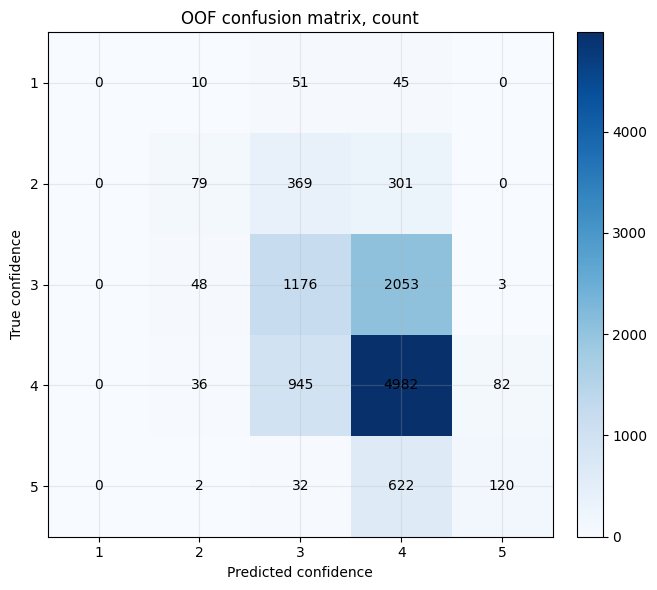

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\plots\confusion_matrix_row_normalized.png


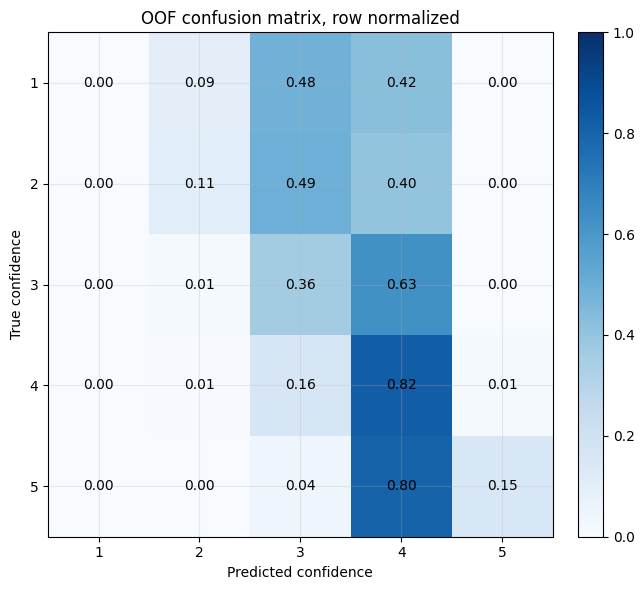

In [8]:
def savefig(name):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    print("saved:", path)


# Confusion matrix: raw count
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(range(5), labels=[1, 2, 3, 4, 5])
ax.set_yticks(range(5), labels=[1, 2, 3, 4, 5])
ax.set_xlabel("Predicted confidence")
ax.set_ylabel("True confidence")
ax.set_title("OOF confusion matrix, count")
for i in range(5):
    for j in range(5):
        ax.text(j, i, str(cm.values[i, j]), ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
savefig("confusion_matrix_count.png")
plt.show()


# Confusion matrix: row normalized recall view
cm_norm = cm.values / np.maximum(cm.values.sum(axis=1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(5), labels=[1, 2, 3, 4, 5])
ax.set_yticks(range(5), labels=[1, 2, 3, 4, 5])
ax.set_xlabel("Predicted confidence")
ax.set_ylabel("True confidence")
ax.set_title("OOF confusion matrix, row normalized")
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
savefig("confusion_matrix_row_normalized.png")
plt.show()

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\plots\per_class_metrics.png


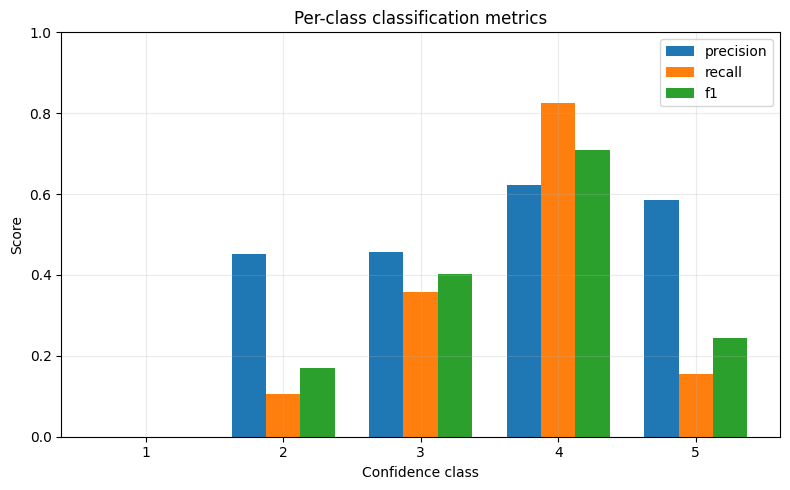

C:\Users\solok\AppData\Local\Temp\ipykernel_13792\3750550786.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[1, 2, 3, 4, 5], showfliers=False)


saved: c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\plots\predicted_score_by_true_confidence_boxplot.png


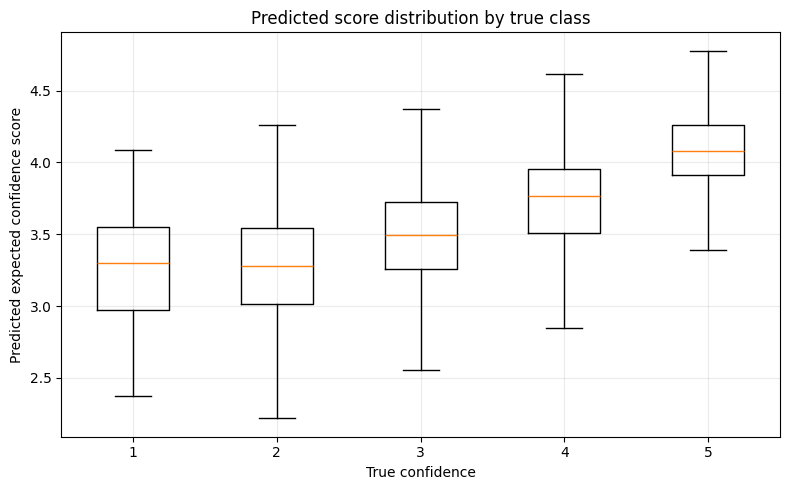

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\plots\true_vs_predicted_class_distribution.png


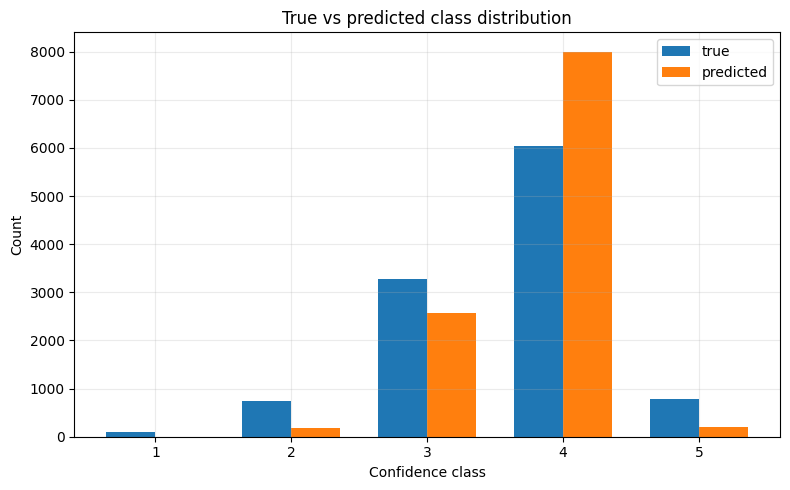

In [9]:
# Per-class precision / recall / F1
fig, ax = plt.subplots(figsize=(8, 5))
xpos = np.arange(len(per_class_df))
width = 0.25
ax.bar(xpos - width, per_class_df["precision"], width=width, label="precision")
ax.bar(xpos, per_class_df["recall"], width=width, label="recall")
ax.bar(xpos + width, per_class_df["f1"], width=width, label="f1")
ax.set_xticks(xpos, labels=per_class_df["confidence"].astype(str))
ax.set_ylim(0, 1)
ax.set_xlabel("Confidence class")
ax.set_ylabel("Score")
ax.set_title("Per-class classification metrics")
ax.legend()
savefig("per_class_metrics.png")
plt.show()


# Predicted score distribution by true confidence
fig, ax = plt.subplots(figsize=(8, 5))
data = [oof_out.loc[oof_out["true_confidence"] == cls, "predicted_confidence_score"].values for cls in [1, 2, 3, 4, 5]]
ax.boxplot(data, labels=[1, 2, 3, 4, 5], showfliers=False)
ax.set_xlabel("True confidence")
ax.set_ylabel("Predicted expected confidence score")
ax.set_title("Predicted score distribution by true class")
savefig("predicted_score_by_true_confidence_boxplot.png")
plt.show()


# Prediction class distribution vs true class distribution
true_counts = pd.Series(y_1based).value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
pred_counts = pd.Series(oof_out["predicted_confidence_class"]).value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
fig, ax = plt.subplots(figsize=(8, 5))
xpos = np.arange(5)
ax.bar(xpos - 0.18, true_counts.values, width=0.36, label="true")
ax.bar(xpos + 0.18, pred_counts.values, width=0.36, label="predicted")
ax.set_xticks(xpos, labels=[1, 2, 3, 4, 5])
ax.set_xlabel("Confidence class")
ax.set_ylabel("Count")
ax.set_title("True vs predicted class distribution")
ax.legend()
savefig("true_vs_predicted_class_distribution.png")
plt.show()

## Visualizations: hidden embedding clustering

`oof_hidden`은 각 fold에서 validation sample을 통과시켜 얻은 MLP 마지막 hidden layer 256-d embedding입니다. 즉 학습에 직접 본 sample이 아니라 OOF 방식으로 얻은 hidden representation입니다.

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\plots\hidden_pca_true_vs_predicted.png


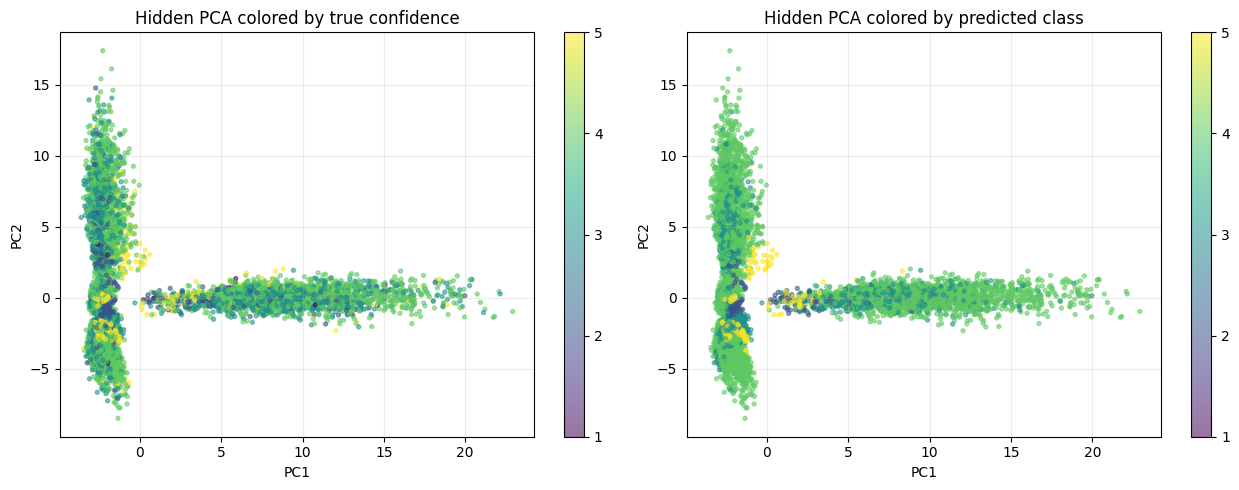

PCA explained variance ratio: [0.19599849 0.1058485 ]


In [10]:
# PCA clustering view
pca = PCA(n_components=2, random_state=CONFIG["seed"])
hidden_pca = pca.fit_transform(oof_hidden)

pca_df = pd.DataFrame({
    "pc1": hidden_pca[:, 0],
    "pc2": hidden_pca[:, 1],
    "true_confidence": y_1based,
    "predicted_confidence_class": oof_out["predicted_confidence_class"].to_numpy(),
    "predicted_confidence_score": oof_out["predicted_confidence_score"].to_numpy(),
})
pca_df.to_csv(REPORT_DIR / "kang_study_hidden_pca.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter = axes[0].scatter(pca_df["pc1"], pca_df["pc2"], c=pca_df["true_confidence"], s=8, alpha=0.55, cmap="viridis", vmin=1, vmax=5)
axes[0].set_title("Hidden PCA colored by true confidence")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(scatter, ax=axes[0], ticks=[1, 2, 3, 4, 5])

scatter = axes[1].scatter(pca_df["pc1"], pca_df["pc2"], c=pca_df["predicted_confidence_class"], s=8, alpha=0.55, cmap="viridis", vmin=1, vmax=5)
axes[1].set_title("Hidden PCA colored by predicted class")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
fig.colorbar(scatter, ax=axes[1], ticks=[1, 2, 3, 4, 5])
savefig("hidden_pca_true_vs_predicted.png")
plt.show()

print("PCA explained variance ratio:", pca.explained_variance_ratio_)

saved: c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\plots\hidden_tsne_true_vs_predicted.png


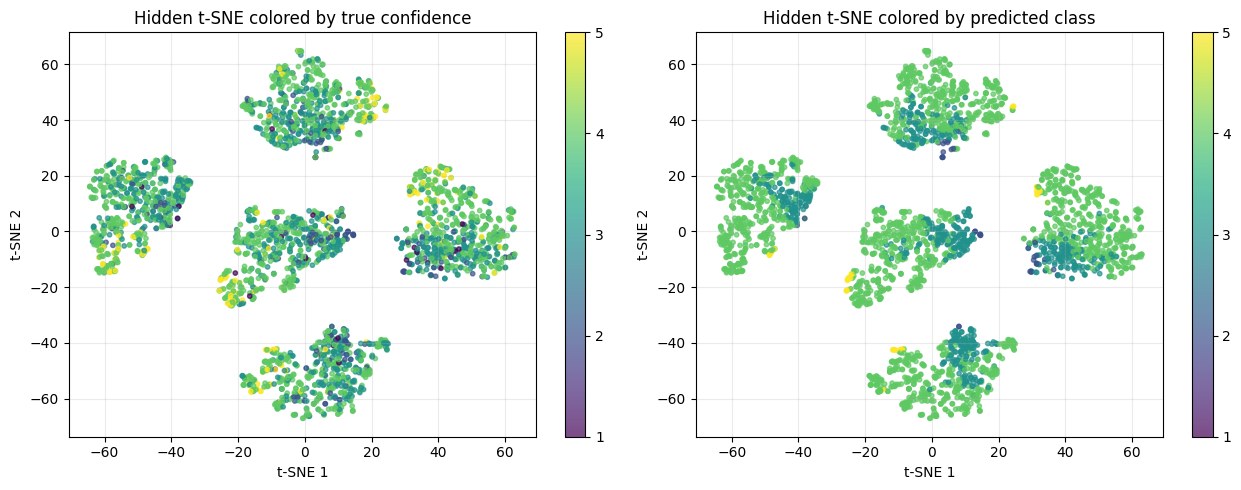

In [11]:
# t-SNE clustering view. This can take a bit on CPU, so it samples rows.
rng = np.random.default_rng(CONFIG["seed"])
sample_n = min(CONFIG["tsne_sample_n"], len(oof_hidden))
sample_idx = rng.choice(len(oof_hidden), size=sample_n, replace=False)

tsne = TSNE(n_components=2, perplexity=35, learning_rate="auto", init="pca", random_state=CONFIG["seed"])
hidden_tsne = tsne.fit_transform(oof_hidden[sample_idx])

tsne_df = pd.DataFrame({
    "tsne1": hidden_tsne[:, 0],
    "tsne2": hidden_tsne[:, 1],
    "true_confidence": y_1based[sample_idx],
    "predicted_confidence_class": oof_out["predicted_confidence_class"].to_numpy()[sample_idx],
    "predicted_confidence_score": oof_out["predicted_confidence_score"].to_numpy()[sample_idx],
})
tsne_df.to_csv(REPORT_DIR / "kang_study_hidden_tsne_sample.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
scatter = axes[0].scatter(tsne_df["tsne1"], tsne_df["tsne2"], c=tsne_df["true_confidence"], s=10, alpha=0.7, cmap="viridis", vmin=1, vmax=5)
axes[0].set_title("Hidden t-SNE colored by true confidence")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
fig.colorbar(scatter, ax=axes[0], ticks=[1, 2, 3, 4, 5])

scatter = axes[1].scatter(tsne_df["tsne1"], tsne_df["tsne2"], c=tsne_df["predicted_confidence_class"], s=10, alpha=0.7, cmap="viridis", vmin=1, vmax=5)
axes[1].set_title("Hidden t-SNE colored by predicted class")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
fig.colorbar(scatter, ax=axes[1], ticks=[1, 2, 3, 4, 5])
savefig("hidden_tsne_true_vs_predicted.png")
plt.show()

t-SNE cluster analysis start
SEED: 42
N_CLUSTERS: 5

[1] KMeans clustering completed


tsne_cluster
0    639
1    576
2    578
3    610
4    597
Name: count, dtype: int64


[2] Detailed cluster dataframe saved
c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\reports\kang_study_tsne_cluster_detail.csv

[3] Cluster summary


,cluster,n_samples,mean_true_confidence,std_true_confidence,mean_predicted_score,std_predicted_score,dominant_true_confidence,dominant_true_confidence_rate,dominant_predicted_class,dominant_predicted_class_rate,dominant_class_top,dominant_class_top_rate,dominant_class,dominant_class_rate
0,0,639,3.622848,0.769833,3.679800,0.470226,4,0.560250,4,0.724570,fx,0.380282,fx-o,0.115806
1,1,576,3.625000,0.723518,3.621177,0.336782,4,0.572917,4,0.779514,fx,0.376736,fx-o,0.121528
2,2,578,3.572664,0.753327,3.638323,0.367731,4,0.524221,4,0.716263,fx,0.354671,fx-o,0.095156
3,3,610,3.637705,0.723671,3.618430,0.432600,4,0.578689,4,0.750820,fx,0.403279,fx-o,0.124590
4,4,597,3.599665,0.774293,3.608817,0.373293,4,0.539363,4,0.700168,fx,0.407035,fx-o,0.130653



[4] Cluster vs TRUE confidence


...


[8] Representative samples


,tsne_cluster,sound_id,class_top,class,true_confidence,predicted_confidence_class,predicted_confidence_score,distance_to_cluster_center
1988,0,48397,fx,fx-a,3,4,3.847560,0.682451
977,0,84441,fx,fx-a,4,4,3.753455,0.736290
1168,0,167455,fx,fx-a,4,3,3.481677,0.768837
2110,0,13533,fx,fx-a,2,3,3.458665,0.916431
2414,0,40067,m,m-si,4,4,3.765712,1.554841
...,...,...,...,...,...,...,...,...
1047,4,73203,ss,ss-n,3,4,3.524741,2.783508
480,4,208848,fx,fx-a,2,4,3.578638,3.031554
2121,4,333610,is,is-p,4,4,3.449435,3.051801
821,4,52758,fx,fx-o,3,3,3.424470,3.128525



[9] Cluster-label agreement


,comparison,ARI,NMI
0,tsne_cluster vs true_confidence,-0.000048,0.001286
1,tsne_cluster vs predicted_confidence_class,0.000302,0.006090
2,tsne_cluster vs class_top,-0.000064,0.001284
3,tsne_cluster vs class,0.000082,0.006574



[10] Silhouette score on t-SNE coordinates
silhouette = 0.6371021866798401


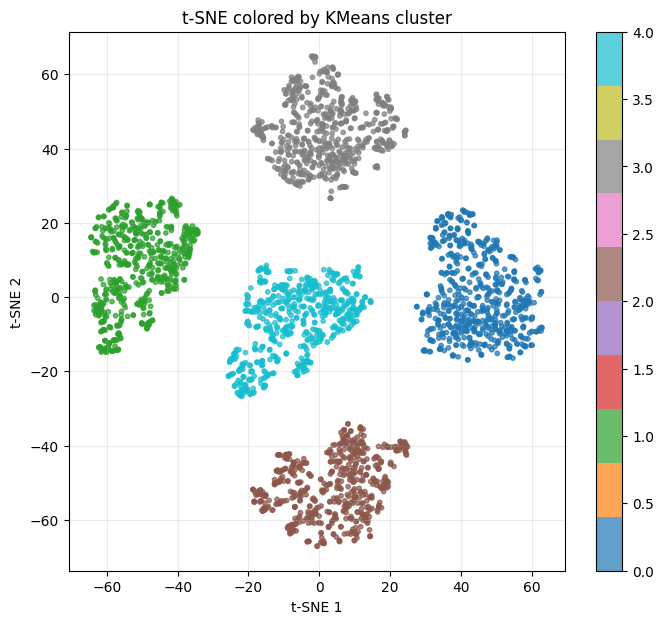


[11] Cluster plot saved
c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\plots\hidden_tsne_kmeans_clusters.png

ALL OUTPUT FILES
c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\reports\kang_study_tsne_cluster_detail.csv
c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\reports\kang_study_tsne_cluster_summary.csv
c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\reports\kang_study_tsne_cluster_true_confidence_rate.csv
c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\reports\kang_study_tsne_cluster_predicted_class_rate.csv
c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\reports\kang_study_tsne_cluster_representative_samples.csv
c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\reports\kang_study_tsne_cluster_label_agreement.csv
c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\plots\hidden_tsne_kmeans_clusters.png
c:\Users\solok\Desktop\Dcase baseline\outputs\kang_study\reports\kang_study_tsne_cluster_class_top_rate.csv
c:\Us

In [13]:
# ============================================================
# kang_study t-SNE cluster 전체 분석 코드
# t-SNE 시각화 코드 바로 아래 셀에 붙여서 실행
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 0. 안전 설정
# ============================================================

SEED = CONFIG["seed"] if "CONFIG" in globals() else 42
N_CLUSTERS = 5

# REPORT_DIR / PLOT_DIR 없을 때 대비
if "REPORT_DIR" not in globals():
    REPORT_DIR = Path("./reports")
    REPORT_DIR.mkdir(parents=True, exist_ok=True)

if "PLOT_DIR" not in globals():
    PLOT_DIR = Path("./plots")
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

# 필수 변수 확인
required_vars = [
    "tsne_df",
    "sample_idx",
    "bsd10k_df",
]

missing_vars = [
    v for v in required_vars
    if v not in globals()
]

if missing_vars:
    raise NameError(
        f"다음 변수가 없습니다: {missing_vars}\n"
        "위쪽 셀을 먼저 실행해야 합니다.\n"
        "특히 t-SNE 시각화 셀까지 실행한 뒤 이 셀을 실행하세요."
    )

print("=" * 80)
print("t-SNE cluster analysis start")
print("=" * 80)
print("SEED:", SEED)
print("N_CLUSTERS:", N_CLUSTERS)

# ============================================================
# 1. t-SNE cluster 생성
# ============================================================

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=SEED,
    n_init=20
)

tsne_df = tsne_df.copy()

tsne_df["tsne_cluster"] = kmeans.fit_predict(
    tsne_df[["tsne1", "tsne2"]]
)

print("\n[1] KMeans clustering completed")
display(tsne_df["tsne_cluster"].value_counts().sort_index())

# ============================================================
# 2. 원본 metadata 연결
# ============================================================

cluster_detail_df = tsne_df.copy()
cluster_detail_df["original_index"] = sample_idx

possible_cols = [
    "sound_id",
    "class",
    "class_top",
    "split",
    "fold",
    "title",
    "tags",
    "description",
    "confidence",
]

for col in possible_cols:
    if col in bsd10k_df.columns:
        cluster_detail_df[col] = (
            bsd10k_df.iloc[sample_idx][col]
            .to_numpy()
        )

cluster_detail_df = cluster_detail_df.sort_values(
    ["tsne_cluster", "true_confidence"]
)

detail_path = REPORT_DIR / "kang_study_tsne_cluster_detail.csv"
cluster_detail_df.to_csv(detail_path, index=False)

print("\n[2] Detailed cluster dataframe saved")
print(detail_path)

# ============================================================
# 3. cluster 요약
# ============================================================

cluster_summary = []

for c in sorted(cluster_detail_df["tsne_cluster"].unique()):

    sub = cluster_detail_df[
        cluster_detail_df["tsne_cluster"] == c
    ]

    row = {
        "cluster": c,
        "n_samples": len(sub),

        "mean_true_confidence":
            sub["true_confidence"].mean(),

        "std_true_confidence":
            sub["true_confidence"].std(),

        "mean_predicted_score":
            sub["predicted_confidence_score"].mean(),

        "std_predicted_score":
            sub["predicted_confidence_score"].std(),

        "dominant_true_confidence":
            sub["true_confidence"].mode().iloc[0],

        "dominant_true_confidence_rate":
            sub["true_confidence"]
            .value_counts(normalize=True)
            .max(),

        "dominant_predicted_class":
            sub["predicted_confidence_class"]
            .mode()
            .iloc[0],

        "dominant_predicted_class_rate":
            sub["predicted_confidence_class"]
            .value_counts(normalize=True)
            .max(),
    }

    if "class_top" in sub.columns:
        row["dominant_class_top"] = (
            sub["class_top"].mode().iloc[0]
        )

        row["dominant_class_top_rate"] = (
            sub["class_top"]
            .value_counts(normalize=True)
            .max()
        )

    if "class" in sub.columns:
        row["dominant_class"] = (
            sub["class"].mode().iloc[0]
        )

        row["dominant_class_rate"] = (
            sub["class"]
            .value_counts(normalize=True)
            .max()
        )

    cluster_summary.append(row)

cluster_summary_df = pd.DataFrame(cluster_summary)

summary_path = REPORT_DIR / "kang_study_tsne_cluster_summary.csv"
cluster_summary_df.to_csv(summary_path, index=False)

print("\n[3] Cluster summary")
display(cluster_summary_df)

# ============================================================
# 4. cluster별 true confidence 비율
# ============================================================

true_conf_crosstab = pd.crosstab(
    cluster_detail_df["tsne_cluster"],
    cluster_detail_df["true_confidence"],
    normalize="index"
)

true_conf_path = REPORT_DIR / "kang_study_tsne_cluster_true_confidence_rate.csv"
true_conf_crosstab.to_csv(true_conf_path)

print("\n[4] Cluster vs TRUE confidence")
display(true_conf_crosstab)

# ============================================================
# 5. cluster별 predicted confidence class 비율
# ============================================================

pred_conf_crosstab = pd.crosstab(
    cluster_detail_df["tsne_cluster"],
    cluster_detail_df["predicted_confidence_class"],
    normalize="index"
)

pred_conf_path = REPORT_DIR / "kang_study_tsne_cluster_predicted_class_rate.csv"
pred_conf_crosstab.to_csv(pred_conf_path)

print("\n[5] Cluster vs PREDICTED confidence")
display(pred_conf_crosstab)

# ============================================================
# 6. cluster별 class_top 비율
# ============================================================

if "class_top" in cluster_detail_df.columns:

    class_top_crosstab = pd.crosstab(
        cluster_detail_df["tsne_cluster"],
        cluster_detail_df["class_top"],
        normalize="index"
    )

    class_top_path = REPORT_DIR / "kang_study_tsne_cluster_class_top_rate.csv"
    class_top_crosstab.to_csv(class_top_path)

    print("\n[6] Cluster vs class_top")
    display(class_top_crosstab)

else:
    class_top_path = None
    print("\n[6] class_top column not found")

# ============================================================
# 7. cluster별 세부 class TOP 10
# ============================================================

if "class" in cluster_detail_df.columns:

    rows = []

    for c in sorted(cluster_detail_df["tsne_cluster"].unique()):

        sub = cluster_detail_df[
            cluster_detail_df["tsne_cluster"] == c
        ]

        vc = (
            sub["class"]
            .value_counts(normalize=True)
            .head(10)
        )

        for cls, rate in vc.items():
            rows.append({
                "cluster": c,
                "class": cls,
                "rate": rate,
                "count": int((sub["class"] == cls).sum())
            })

    cluster_class_top10_df = pd.DataFrame(rows)

    class_top10_path = REPORT_DIR / "kang_study_tsne_cluster_class_top10.csv"
    cluster_class_top10_df.to_csv(class_top10_path, index=False)

    print("\n[7] Cluster class TOP10")
    display(cluster_class_top10_df)

else:
    class_top10_path = None
    print("\n[7] class column not found")

# ============================================================
# 8. cluster별 중심에 가까운 대표 sample 추출
# ============================================================

representative_rows = []
centers = kmeans.cluster_centers_

for c in sorted(cluster_detail_df["tsne_cluster"].unique()):

    sub = cluster_detail_df[
        cluster_detail_df["tsne_cluster"] == c
    ].copy()

    center = centers[c]

    sub["distance_to_cluster_center"] = np.sqrt(
        (sub["tsne1"] - center[0]) ** 2 +
        (sub["tsne2"] - center[1]) ** 2
    )

    rep = (
        sub.sort_values("distance_to_cluster_center")
        .head(20)
    )

    representative_rows.append(rep)

representative_df = pd.concat(representative_rows, axis=0)

rep_path = REPORT_DIR / "kang_study_tsne_cluster_representative_samples.csv"
representative_df.to_csv(rep_path, index=False)

print("\n[8] Representative samples")

cols_to_show = [
    "tsne_cluster",
    "sound_id",
    "class_top",
    "class",
    "true_confidence",
    "predicted_confidence_class",
    "predicted_confidence_score",
    "distance_to_cluster_center",
]

cols_to_show = [
    c for c in cols_to_show
    if c in representative_df.columns
]

display(representative_df[cols_to_show].head(100))

# ============================================================
# 9. cluster와 label의 일치도 확인
# ============================================================

agreement_rows = []

def add_agreement(label_col):
    if label_col in cluster_detail_df.columns:

        ari = adjusted_rand_score(
            cluster_detail_df["tsne_cluster"],
            cluster_detail_df[label_col]
        )

        nmi = normalized_mutual_info_score(
            cluster_detail_df["tsne_cluster"],
            cluster_detail_df[label_col]
        )

        agreement_rows.append({
            "comparison": f"tsne_cluster vs {label_col}",
            "ARI": ari,
            "NMI": nmi
        })

for label_col in [
    "true_confidence",
    "predicted_confidence_class",
    "class_top",
    "class",
]:
    add_agreement(label_col)

agreement_df = pd.DataFrame(agreement_rows)

agreement_path = REPORT_DIR / "kang_study_tsne_cluster_label_agreement.csv"
agreement_df.to_csv(agreement_path, index=False)

print("\n[9] Cluster-label agreement")
display(agreement_df)

# ============================================================
# 10. silhouette score
# ============================================================

sil = silhouette_score(
    tsne_df[["tsne1", "tsne2"]],
    tsne_df["tsne_cluster"]
)

print("\n[10] Silhouette score on t-SNE coordinates")
print("silhouette =", sil)

# ============================================================
# 11. cluster 시각화 저장
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

scatter = ax.scatter(
    tsne_df["tsne1"],
    tsne_df["tsne2"],
    c=tsne_df["tsne_cluster"],
    s=10,
    alpha=0.7,
    cmap="tab10"
)

ax.set_title("t-SNE colored by KMeans cluster")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.colorbar(scatter, ax=ax)

cluster_plot_path = PLOT_DIR / "hidden_tsne_kmeans_clusters.png"

plt.savefig(cluster_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("\n[11] Cluster plot saved")
print(cluster_plot_path)

# ============================================================
# 12. 최종 저장 파일 목록
# ============================================================

print("\n" + "=" * 80)
print("ALL OUTPUT FILES")
print("=" * 80)

output_files = [
    detail_path,
    summary_path,
    true_conf_path,
    pred_conf_path,
    rep_path,
    agreement_path,
    cluster_plot_path,
]

if class_top_path is not None:
    output_files.append(class_top_path)

if class_top10_path is not None:
    output_files.append(class_top10_path)

for f in output_files:
    print(f)

print("\nAnalysis complete.")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

PLOT_DIR = OUT_DIR / "plots"
REPORT_DIR = OUT_DIR / "reports"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160)
    print("saved:", path)


# Load one trained fold model and inspect classifier weights.
# You can change fold_0.pt to another fold checkpoint.
ckpt_path = CKPT_DIR / "fold_0.pt"
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

model = ConfidenceMLP(
    ckpt["input_dim"],
    hidden=CONFIG["hidden"],
    dropout=CONFIG["dropout"],
).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

W = model.classifier.weight.detach().cpu().numpy()  # shape: [5, 256]
b = model.classifier.bias.detach().cpu().numpy()    # shape: [5]

print("classifier weight shape:", W.shape)
print("classifier bias:", b)


# 1. Classifier weight heatmap
plt.figure(figsize=(12, 4))
plt.imshow(W, aspect="auto", cmap="coolwarm")
plt.colorbar(label="weight value")
plt.yticks(range(5), [f"conf {i}" for i in range(1, 6)])
plt.xlabel("hidden dimension")
plt.ylabel("output class")
plt.title("Final classifier weight matrix: confidence class heads")
savefig("classifier_weight_heatmap.png")
plt.show()


# 2. Pairwise cosine distance between confidence class weight vectors
dist = pairwise_distances(W, metric="cosine")
dist_df = pd.DataFrame(
    dist,
    index=[f"conf_{i}" for i in range(1, 6)],
    columns=[f"conf_{i}" for i in range(1, 6)],
)
display(dist_df)
dist_df.to_csv(REPORT_DIR / "classifier_weight_cosine_distance.csv")

plt.figure(figsize=(6, 5))
plt.imshow(dist, cmap="viridis", vmin=0)
plt.colorbar(label="cosine distance")
plt.xticks(range(5), [1, 2, 3, 4, 5])
plt.yticks(range(5), [1, 2, 3, 4, 5])
plt.xlabel("confidence class")
plt.ylabel("confidence class")
plt.title("Cosine distance between classifier weight vectors")

for i in range(5):
    for j in range(5):
        plt.text(j, i, f"{dist[i, j]:.2f}", ha="center", va="center", color="white")

savefig("classifier_weight_cosine_distance.png")
plt.show()


# 3. PCA of classifier weight vectors
# This shows where the five confidence heads lie in classifier-weight space.
pca = PCA(n_components=2, random_state=CONFIG["seed"])
W_pca = pca.fit_transform(W)

weight_pca_df = pd.DataFrame({
    "confidence_class": [1, 2, 3, 4, 5],
    "pc1": W_pca[:, 0],
    "pc2": W_pca[:, 1],
    "bias": b,
    "weight_norm": np.linalg.norm(W, axis=1),
})
display(weight_pca_df)
weight_pca_df.to_csv(REPORT_DIR / "classifier_weight_pca.csv", index=False)

plt.figure(figsize=(7, 6))
plt.scatter(W_pca[:, 0], W_pca[:, 1], c=[1, 2, 3, 4, 5], cmap="viridis", s=180)

for i, cls in enumerate([1, 2, 3, 4, 5]):
    plt.text(W_pca[i, 0], W_pca[i, 1], f"  conf {cls}", va="center")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    "PCA of final classifier weight vectors\n"
    f"explained variance: {pca.explained_variance_ratio_[0]:.2f}, {pca.explained_variance_ratio_[1]:.2f}"
)
plt.colorbar(label="confidence class")
savefig("classifier_weight_pca.png")
plt.show()


# 4. Project OOF hidden features onto classifier weight PCA axes
# This visualizes sample density in the classifier-head coordinate system.
# Important: PCA was fit on the 5 class-head weight vectors W.
# We project hidden features using the same PCA basis.
hidden_centered = oof_hidden - pca.mean_
hidden_weight_pca = hidden_centered @ pca.components_.T

hidden_weight_pca_df = pd.DataFrame({
    "pc1": hidden_weight_pca[:, 0],
    "pc2": hidden_weight_pca[:, 1],
    "true_confidence": y_1based,
    "predicted_confidence_class": oof_out["predicted_confidence_class"].to_numpy(),
    "predicted_confidence_score": oof_out["predicted_confidence_score"].to_numpy(),
})
hidden_weight_pca_df.to_csv(REPORT_DIR / "hidden_projected_on_classifier_weight_pca.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(
    hidden_weight_pca_df["pc1"],
    hidden_weight_pca_df["pc2"],
    c=hidden_weight_pca_df["true_confidence"],
    cmap="viridis",
    vmin=1,
    vmax=5,
    s=8,
    alpha=0.45,
)
axes[0].scatter(W_pca[:, 0], W_pca[:, 1], c="red", s=160, marker="X", label="class heads")
for i, cls in enumerate([1, 2, 3, 4, 5]):
    axes[0].text(W_pca[i, 0], W_pca[i, 1], f" conf {cls}", color="red")
axes[0].set_title("Hidden samples projected on classifier-weight PCA\ncolored by true confidence")
axes[0].set_xlabel("classifier-weight PC1")
axes[0].set_ylabel("classifier-weight PC2")
axes[0].legend()
fig.colorbar(sc, ax=axes[0], ticks=[1, 2, 3, 4, 5])

sc = axes[1].scatter(
    hidden_weight_pca_df["pc1"],
    hidden_weight_pca_df["pc2"],
    c=hidden_weight_pca_df["predicted_confidence_class"],
    cmap="viridis",
    vmin=1,
    vmax=5,
    s=8,
    alpha=0.45,
)
axes[1].scatter(W_pca[:, 0], W_pca[:, 1], c="red", s=160, marker="X", label="class heads")
for i, cls in enumerate([1, 2, 3, 4, 5]):
    axes[1].text(W_pca[i, 0], W_pca[i, 1], f" conf {cls}", color="red")
axes[1].set_title("Hidden samples projected on classifier-weight PCA\ncolored by predicted class")
axes[1].set_xlabel("classifier-weight PC1")
axes[1].set_ylabel("classifier-weight PC2")
axes[1].legend()
fig.colorbar(sc, ax=axes[1], ticks=[1, 2, 3, 4, 5])

savefig("hidden_projected_on_classifier_weight_pca.png")
plt.show()


# 5. Direct classifier logit space visualization
# This is often more interpretable than t-SNE:
# each sample is represented by the 5 logits from the confidence classifier.
logits_oof = []

for fold in range(CONFIG["folds"]):
    ckpt = torch.load(CKPT_DIR / f"fold_{fold}.pt", map_location=DEVICE, weights_only=False)
    scaler = StandardScaler()
    scaler.mean_ = ckpt["scaler_mean"]
    scaler.scale_ = ckpt["scaler_scale"]
    scaler.var_ = scaler.scale_ ** 2
    scaler.n_features_in_ = len(scaler.mean_)

    model = ConfidenceMLP(
        ckpt["input_dim"],
        hidden=CONFIG["hidden"],
        dropout=CONFIG["dropout"],
    ).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    _, valid_idx = splits[fold]
    x_valid = scaler.transform(x_raw[valid_idx]).astype(np.float32)
    loader = DataLoader(ConfidenceDataset(x_valid), batch_size=CONFIG["batch_size"], shuffle=False)

    fold_logits = []
    with torch.no_grad():
        for batch in loader:
            xb = batch["x"].to(DEVICE)
            fold_logits.append(model(xb).cpu().numpy())

    logits_fold = np.vstack(fold_logits)
    logits_oof.append((valid_idx, logits_fold))

logit_matrix = np.zeros((len(y_1based), 5), dtype=np.float32)
for valid_idx, logits_fold in logits_oof:
    logit_matrix[valid_idx] = logits_fold

logit_df = pd.DataFrame(
    logit_matrix,
    columns=[f"logit_conf_{i}" for i in range(1, 6)]
)
logit_df["true_confidence"] = y_1based
logit_df["predicted_confidence_class"] = oof_out["predicted_confidence_class"].to_numpy()
logit_df["predicted_confidence_score"] = oof_out["predicted_confidence_score"].to_numpy()
logit_df.to_csv(REPORT_DIR / "oof_classifier_logits.csv", index=False)

display(logit_df.head())


# 6. PCA of 5-d logit space
# This shows density after the final confidence classifier, not just hidden embedding.
logit_pca = PCA(n_components=2, random_state=CONFIG["seed"])
logits_2d = logit_pca.fit_transform(logit_matrix)

logit_pca_df = pd.DataFrame({
    "pc1": logits_2d[:, 0],
    "pc2": logits_2d[:, 1],
    "true_confidence": y_1based,
    "predicted_confidence_class": oof_out["predicted_confidence_class"].to_numpy(),
    "predicted_confidence_score": oof_out["predicted_confidence_score"].to_numpy(),
})
logit_pca_df.to_csv(REPORT_DIR / "oof_logit_pca.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(
    logit_pca_df["pc1"],
    logit_pca_df["pc2"],
    c=logit_pca_df["true_confidence"],
    cmap="viridis",
    vmin=1,
    vmax=5,
    s=8,
    alpha=0.5,
)
axes[0].set_title("OOF classifier logit PCA\ncolored by true confidence")
axes[0].set_xlabel("logit PC1")
axes[0].set_ylabel("logit PC2")
fig.colorbar(sc, ax=axes[0], ticks=[1, 2, 3, 4, 5])

sc = axes[1].scatter(
    logit_pca_df["pc1"],
    logit_pca_df["pc2"],
    c=logit_pca_df["predicted_confidence_class"],
    cmap="viridis",
    vmin=1,
    vmax=5,
    s=8,
    alpha=0.5,
)
axes[1].set_title("OOF classifier logit PCA\ncolored by predicted class")
axes[1].set_xlabel("logit PC1")
axes[1].set_ylabel("logit PC2")
fig.colorbar(sc, ax=axes[1], ticks=[1, 2, 3, 4, 5])

savefig("oof_classifier_logit_pca.png")
plt.show()

print("logit PCA explained variance ratio:", logit_pca.explained_variance_ratio_)


# 7. Density of samples by predicted confidence class in logit PC space
# This is useful for seeing whether the classifier creates dense regions for each predicted class.
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharex=True, sharey=True)

for ax, cls in zip(axes, [1, 2, 3, 4, 5]):
    sub = logit_pca_df[logit_pca_df["predicted_confidence_class"] == cls]
    ax.hexbin(
        sub["pc1"],
        sub["pc2"],
        gridsize=35,
        cmap="Blues",
        mincnt=1,
    )
    ax.set_title(f"pred class {cls}\\nn={len(sub)}")
    ax.set_xlabel("logit PC1")
    ax.set_ylabel("logit PC2")

savefig("oof_logit_pca_density_by_predicted_class.png")
plt.show()

In [ ]:
# Numeric clustering diagnostics. Higher silhouette means cleaner separation.
# Because confidence 1 is tiny, treat this as a rough diagnostic, not a final metric.
cluster_rows = []
try:
    cluster_rows.append({
        "space": "hidden_256",
        "label": "true_confidence",
        "silhouette": float(silhouette_score(oof_hidden, y_1based, metric="euclidean")),
    })
except Exception as exc:
    cluster_rows.append({"space": "hidden_256", "label": "true_confidence", "silhouette": np.nan, "error": str(exc)})

try:
    cluster_rows.append({
        "space": "hidden_256",
        "label": "predicted_confidence_class",
        "silhouette": float(silhouette_score(oof_hidden, oof_out["predicted_confidence_class"], metric="euclidean")),
    })
except Exception as exc:
    cluster_rows.append({"space": "hidden_256", "label": "predicted_confidence_class", "silhouette": np.nan, "error": str(exc)})

cluster_df = pd.DataFrame(cluster_rows)
cluster_df.to_csv(REPORT_DIR / "kang_study_clustering_metrics.csv", index=False)
display(cluster_df)

## Optional: train on all BSD10k and predict BSD35k-CS

In [ ]:
RUN_BSD35K_PREDICTION = True


def train_final_full_model(train_epochs):
    seed_everything(CONFIG["seed"])
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_raw).astype(np.float32)
    loader = DataLoader(ConfidenceDataset(x_train, y_0based), batch_size=CONFIG["batch_size"], shuffle=True)

    model = ConfidenceMLP(x_raw.shape[1], hidden=CONFIG["hidden"], dropout=CONFIG["dropout"]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(train_epochs, 1))

    for epoch in range(train_epochs):
        model.train()
        for batch in loader:
            xb = batch["x"].to(DEVICE)
            yb = batch["y"].to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = compute_loss(model(xb), yb, CONFIG["loss_name"])
            loss.backward()
            optimizer.step()
        scheduler.step()

    torch.save(
        {
            "model_state": model.state_dict(),
            "input_dim": int(x_raw.shape[1]),
            "scaler_mean": scaler.mean_.astype(np.float32),
            "scaler_scale": scaler.scale_.astype(np.float32),
            "class_categories": class_categories,
            "config": CONFIG,
            "train_epochs": int(train_epochs),
        },
        CKPT_DIR / "final_full_bsd10k.pt",
    )
    return model, scaler


if RUN_BSD35K_PREDICTION:
    best_epochs = [row["best_epoch"] + 1 for row in fold_rows]
    final_epochs = int(round(float(np.median(best_epochs))))
    final_epochs = max(1, min(CONFIG["epochs"], final_epochs))
    print("final train epochs:", final_epochs)

    final_model, final_scaler = train_final_full_model(final_epochs)

    bsd35k_raw = pd.read_csv(CONFIG["bsd35k_metadata"])
    bsd35k = clean_metadata(bsd35k_raw, require_confidence=False)
    bsd35k_df, bsd35k_x_raw = build_feature_matrix(bsd35k, CONFIG["bsd35k_audio_dir"], CONFIG["bsd35k_text_dir"], class_categories)
    bsd35k_x = final_scaler.transform(bsd35k_x_raw).astype(np.float32)
    bsd35k_loader = DataLoader(ConfidenceDataset(bsd35k_x), batch_size=CONFIG["batch_size"], shuffle=False)
    bsd35k_probs, bsd35k_hidden = predict_probs_and_features(final_model, bsd35k_loader)

    bsd35k_out = bsd35k_df.copy()
    bsd35k_out["predicted_confidence_class"] = bsd35k_probs.argmax(axis=1) + 1
    bsd35k_out["predicted_confidence_score"] = expected_score_from_probs(bsd35k_probs)
    for idx in range(5):
        bsd35k_out[f"prob_confidence_{idx + 1}"] = bsd35k_probs[:, idx]

    bsd35k_path = PRED_DIR / "BSD35k-CS_predicted_kang_study.csv"
    bsd35k_out.to_csv(bsd35k_path, index=False)
    np.save(PRED_DIR / "BSD35k-CS_hidden_kang_study.npy", bsd35k_hidden)

    print("saved:", bsd35k_path)
    print("rows:", len(bsd35k_out))
    print("mean score:", float(bsd35k_out["predicted_confidence_score"].mean()))
    display(bsd35k_out["predicted_confidence_class"].value_counts().sort_index().rename_axis("predicted_class").reset_index(name="n"))